<a href="https://colab.research.google.com/github/Vittoriacrugnolaa/University_projects/blob/main/Student_Dropout/Student_Persistence_Dropout.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/></a>


# Predicting student persistence and dropout from socio-academic features


## Dataset overview

The dataset combines enrollment information, demographic and socioeconomic variables, and academic performance from the first two semesters of undergraduate study.


It contains 4,424 student records, 36 predictors, and one target column.


Dataset source: [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success).


Columns Include:

- Demographics & Personal Context: Marital status, Nationality, Gender, Age at enrollment, Displaced, International

- Socioeconomic Factors: Mother's qualification, Father's qualification, Mother's occupation, Father's occupation, Debtor, Tuition fees up to date, Scholarship holder

- Enrollment & Institutional Factors: Application mode, Application order, Previous qualification, Course, evening attendance, Educational special needs

- Macroeconomic Indicators: Unemployment rate, Inflation rate, GDP

- Academic Performance (1st Semester): Curricular units 1st sem (credited), Curricular units 1st sem (enrolled), Curricular units 1st sem (evaluations), Curricular units 1st sem (approved), Curricular units 1st sem (grade), Curricular units 1st sem (without evaluations)

- Academic Performance (2nd Semester): Curricular units 2nd sem (credited), Curricular units 2nd sem (enrolled), Curricular units 2nd sem (evaluations), Curricular units 2nd sem (approved), Curricular units 2nd sem (grade), Curricular units 2nd sem (without evaluations)

## Objective


The original target has three outcomes: `Graduate`, `Dropout`, and `Enrolled`. This notebook reformulates the task as binary classification: `Dropout` is the positive class, while `Graduate` and `Enrolled` form the non-dropout class.


The model estimates dropout risk from the available socio-academic variables. Because second-semester performance is included, the result should be interpreted as risk monitoring after two semesters rather than an enrollment-time early-warning model.


This analysis can support:


- **Risk monitoring:** identifying students who may need additional support after the first two semesters.


- **Resource allocation:** helping institutions prioritize advising, tutoring, or financial support.


- **Model interpretation:** examining which variables are most strongly associated with the predicted risk.


## Installing and importing libraries

In [1]:
from pathlib import Path
import math
import itertools
import warnings
from joblib import parallel_backend
import numpy as np
import pandas as pd
from scipy.stats import uniform, randint, loguniform

import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    RobustScaler,
    OneHotEncoder,
    LabelEncoder,
    FunctionTransformer,
    PowerTransformer
)
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_selection import SequentialFeatureSelector

from sklearn.pipeline import Pipeline
from sklearn import set_config
from imblearn.pipeline import Pipeline as IMBPipeline

from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler

from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV,
    KFold,
    StratifiedKFold,
    RepeatedStratifiedKFold,
    cross_val_score,
    cross_validate,
    learning_curve,
    validation_curve
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    make_scorer,
    RocCurveDisplay,
    ConfusionMatrixDisplay
)

%matplotlib inline
warnings.filterwarnings("ignore")


## Data loading

The notebook first looks for the dataset inside the repository. If it is not available locally, it loads the same file from the UCI Machine Learning Repository.


In [2]:
DATA_CANDIDATES = [
    Path("data/student_data.csv"),
    Path("Student_Dropout/data/student_data.csv"),
    Path("student_data.csv"),
]
UCI_DATA_URL = "https://archive.ics.uci.edu/static/public/697/data.csv"

data_path = next((path for path in DATA_CANDIDATES if path.exists()), None)
if data_path is not None:
    df = pd.read_csv(data_path)
    print(f"Dataset loaded from {data_path}")
else:
    df = pd.read_csv(UCI_DATA_URL)
    print("Dataset loaded from the UCI Machine Learning Repository")

df


Dataset loaded from data/student_data.csv


,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,1,1,6,9773,1,1,125.0,1,1,1,5,4,122.2,0,0,0,1,1,0,19,0,0,6,7,5,13.600000,0,0,6,8,5,12.666667,0,15.5,2.8,-4.06,Graduate
4420,1,1,2,9773,1,1,120.0,105,1,1,9,9,119.0,1,0,1,0,0,0,18,1,0,6,6,6,12.000000,0,0,6,6,2,11.000000,0,11.1,0.6,2.02,Dropout
4421,1,1,1,9500,1,1,154.0,1,37,37,9,9,149.5,1,0,0,1,0,1,30,0,0,7,8,7,14.912500,0,0,8,9,1,13.500000,0,13.9,-0.3,0.79,Dropout
4422,1,1,1,9147,1,1,180.0,1,37,37,7,4,153.8,1,0,0,1,0,1,20,0,0,5,5,5,13.800000,0,0,5,6,5,12.000000,0,9.4,-0.8,-3.12,Graduate


The raw dataset contains 36 predictors and one target column for 4,424 students.


## Data preprocessing

Now we want to check what type of data is present in the dataset.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital Status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

Most columns are numerical codes or continuous measurements. The target column, `Target`, contains the three outcome labels.


The three-class target is converted into `is_dropout`: dropout is encoded as 1, while graduate and enrolled students are encoded as 0.


In [4]:
df['Is_Dropout'] = df['Target'].map({
    'Dropout': 1,
    'Graduate': 0,
    'Enrolled': 0
})

df = df.drop('Target', axis=1)
y = df['Is_Dropout']


Column names are standardized for consistent use throughout the analysis. The misspelled source column `Nacionality` is also corrected.


In [5]:
# Rename 'Nacionality' to 'Nationality'
df.rename(columns={'Nacionality': 'Nationality'}, inplace=True)

In [6]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace(r'[^a-z0-9_]+', '', regex=True)

### Feature engineering

The available columns are reviewed before modeling to reduce redundancy and keep the final feature set interpretable.


Enrollment counts overlap with several other academic activity measures, so they are used to build two more concise features.


Two ratios are created for each semester: a completion ratio and an engagement indicator.


`completion_ratio` is the share of enrolled curricular units that were approved. It summarizes academic completion while handling students with zero enrolled units.


`engagement_indicator` is the number of enrolled curricular units minus units without evaluation. Higher values indicate participation in more assessed units.


In [7]:
approved_1 = 'curricular_units_1st_sem_approved'
enrolled_1 = 'curricular_units_1st_sem_enrolled'
without_eval_1 = 'curricular_units_1st_sem_without_evaluations'

approved_2 = 'curricular_units_2nd_sem_approved'
enrolled_2 = 'curricular_units_2nd_sem_enrolled'
without_eval_2 = 'curricular_units_2nd_sem_without_evaluations'

# Calculate Completion Ratios (handling division by zero)
df['completion_ratio_1st_sem'] = np.where(
    df[enrolled_1] > 0,
    df[approved_1] / df[enrolled_1],
    0.0
)

df['completion_ratio_2nd_sem'] = np.where(
    df[enrolled_2] > 0,
    df[approved_2] / df[enrolled_2],
    0.0
)

# Calculate Engagement Indicators
df['engagement_indicator_1st_sem'] = df[enrolled_1] - df[without_eval_1]
df['engagement_indicator_2nd_sem'] = df[enrolled_2] - df[without_eval_2]

The source columns used to build these features are then removed.


In [8]:
columns_to_drop = [
    'curricular_units_1st_sem_enrolled',
    'curricular_units_2nd_sem_enrolled',
    'curricular_units_1st_sem_evaluations',
    'curricular_units_2nd_sem_evaluations',
    'curricular_units_1st_sem_without_evaluations',
    'curricular_units_2nd_sem_without_evaluations'
    ]

# Drop the columns
df = df.drop(columns=columns_to_drop, axis=1)

The numbers of approved units are retained alongside the ratios because they distinguish different course loads with the same completion rate.


A small set of administrative or redundant variables is removed to keep the analysis focused.


- `application_order` and `application_mode` are omitted because the analysis prioritizes observed academic performance after enrollment.


- `international` is omitted because closely related nationality information is already available.


In [9]:
columns_to_drop = [
    'application_order', # not a strong indicator of future academic success or struggle
    'application_mode', # not a strong indicator of future academic success or struggle
    'international' # already included in nationality
    ]


df = df.drop(columns=columns_to_drop, axis=1)

Feature distributions are inspected to identify variables with very limited variation.


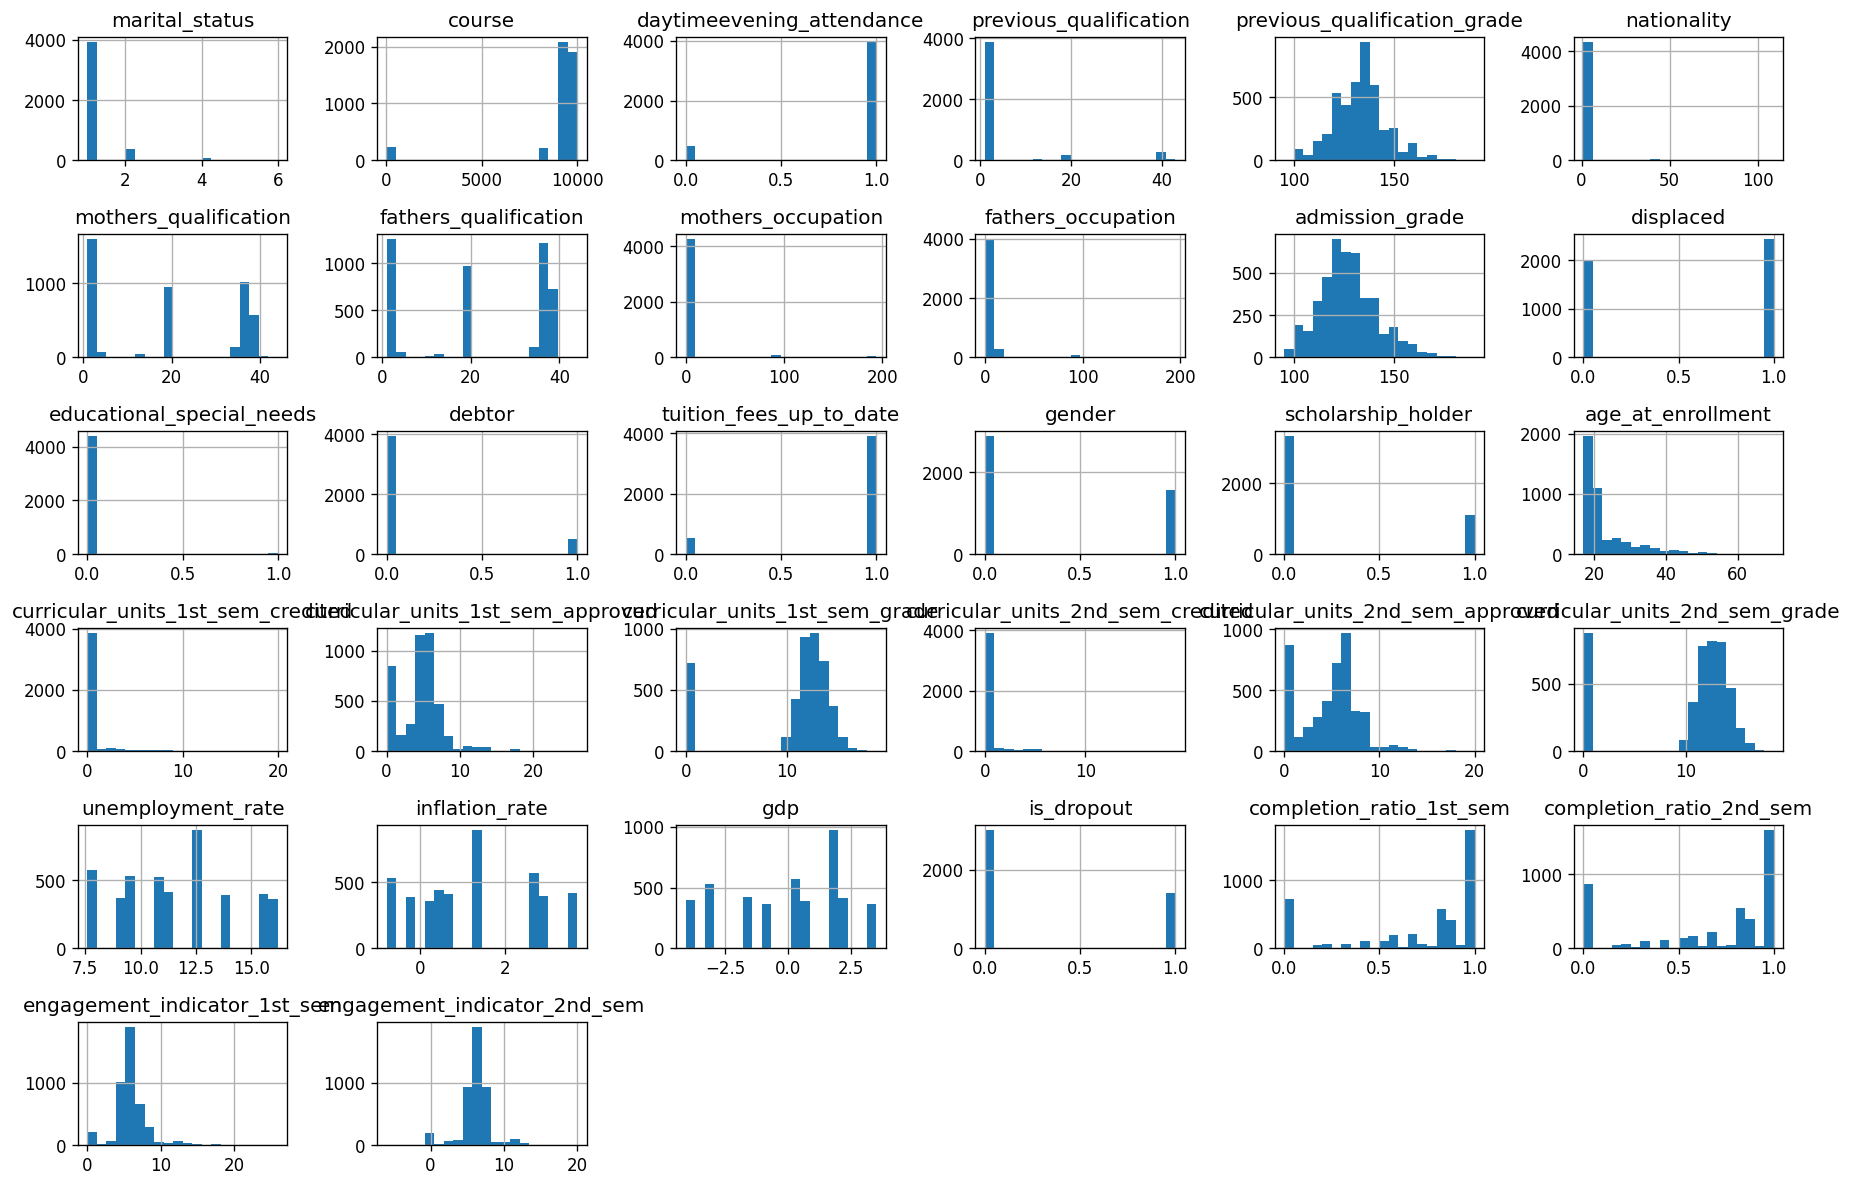

In [10]:
df.hist(bins=20, figsize=(15, 10))
plt.tight_layout()
plt.show()

Columns with very limited variation in this sample are removed because they contribute little information to the comparison.


In [11]:
columns_to_drop = [
    'educational_special_needs',
    'nationality',
    'curricular_units_1st_sem_credited',
    'curricular_units_2nd_sem_credited'
]

df = df.drop(columns=columns_to_drop, axis=1)

First- and second-semester academic measures are strongly related. To reduce redundancy, the model retains the more recent second-semester measures. This choice also means that the predictions describe risk after two semesters, not at initial enrollment.


In [12]:
cols_to_drop = [
    'curricular_units_1st_sem_approved',
    'curricular_units_1st_sem_grade',
    'completion_ratio_1st_sem',
    'engagement_indicator_1st_sem'
]

df = df.drop(cols_to_drop, axis=1)

### Handling missing data

Now we check the quality of our dataset by evaluating the number of missing values in each column.

In [13]:
df.isnull().sum(axis=0)

marital_status                       0
course                               0
daytimeevening_attendance            0
previous_qualification               0
previous_qualification_grade         0
mothers_qualification                0
fathers_qualification                0
mothers_occupation                   0
fathers_occupation                   0
admission_grade                      0
displaced                            0
debtor                               0
tuition_fees_up_to_date              0
gender                               0
scholarship_holder                   0
age_at_enrollment                    0
curricular_units_2nd_sem_approved    0
curricular_units_2nd_sem_grade       0
unemployment_rate                    0
inflation_rate                       0
gdp                                  0
is_dropout                           0
completion_ratio_2nd_sem             0
engagement_indicator_2nd_sem         0
dtype: int64

The published dataset contains no missing values. The pipeline still includes imputers so that the same preprocessing remains usable if future records contain incomplete fields.


No artificial missing values are introduced: model evaluation is performed on the original published observations.


The missing-value matrix below confirms that the working dataset is complete.


In [14]:
missing_counts = df.isnull().sum()
print("Missing values in the published dataset:")
print(missing_counts[missing_counts > 0])
print(f"Total missing values: {int(missing_counts.sum())}")


Missing values in the published dataset:
Series([], dtype: int64)
Total missing values: 0


Let's visualize our dataset to assess the presence of missing values.

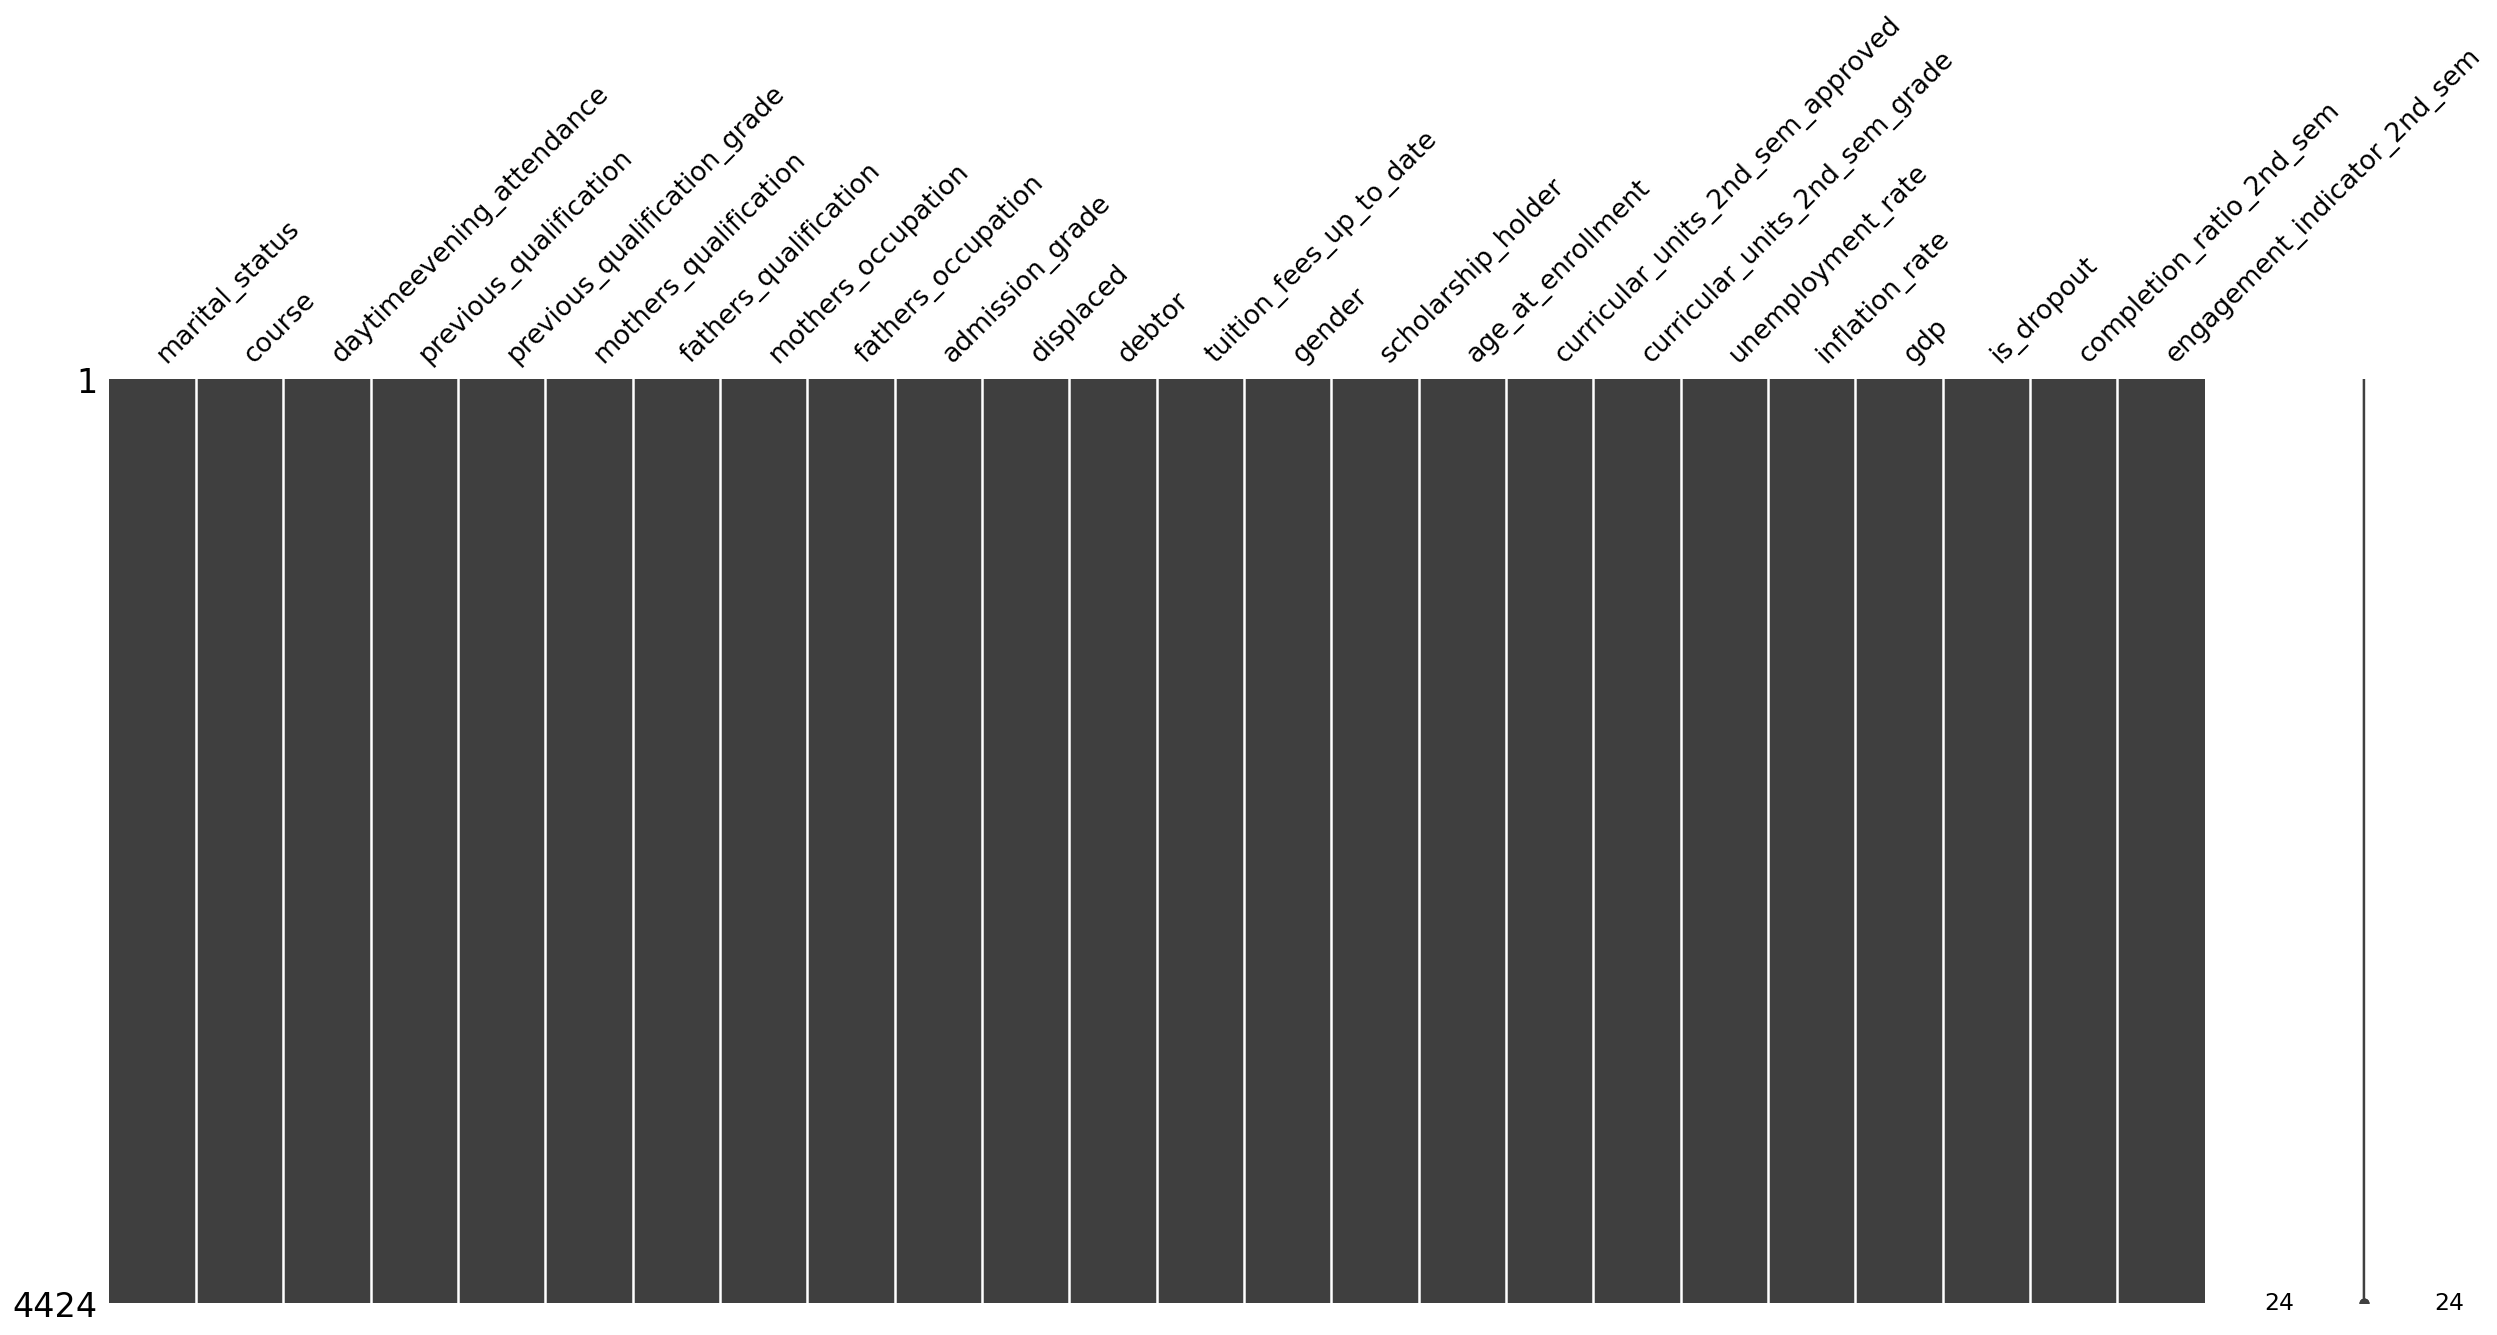

In [15]:
msno.matrix(df)

### Preprocessing pipeline


Each group of variables is transformed according to its data type before it reaches the classifier.


1. Numerical columns

In [16]:
numerical_columns = [
    'previous_qualification_grade',
    'admission_grade',
    'inflation_rate',
    'gdp',
    'unemployment_rate',
    'completion_ratio_2nd_sem',
    'engagement_indicator_2nd_sem'
]


- Mean imputation (SimpleImputer(strategy='mean')) is used to handle missing data.

- Standard scaling (StandardScaler()) standardizes all numerical features (mean = 0, std = 1), ensuring that each contributes equally during model training.

2. Columns that lean heavily to one side (High Skewness)

In [17]:
skewed_columns = [
    'age_at_enrollment'
]

A logarithmic transformation is applied to the skewed age variable before standardization.


- Standard scaling (StandardScaler()) standardizes all numerical features (mean = 0, std = 1), ensuring that each contributes equally during model training.

In [18]:
robust_columns = [
    'curricular_units_2nd_sem_approved',
    'curricular_units_2nd_sem_grade'
]

- Mean imputation (SimpleImputer(strategy='median')) is used to handle missing data.

- Robust scaling (RobustScaler()) scales all numerical features using the median and Interquartile Range (IQR), reducing the influence of outliers during model training.

3. Binary columns

In [19]:
yesno_columns = [
    'daytimeevening_attendance',
    'displaced',
    'gender',
    'scholarship_holder',
    'debtor',
    'tuition_fees_up_to_date'
]


- Most-frequent imputation is used for binary variables if a future input contains a missing value.


4. Nominal categorical columns

In [20]:
nominal_categorical = [
    'marital_status',
    'course',
    'previous_qualification',
    'mothers_qualification',
    'fathers_qualification',
    'mothers_occupation',
    'fathers_occupation'
]


- Most-frequent imputation and one-hot encoding are used for nominal categorical variables. Rare and previously unseen categories are handled by the encoder.


- One-hot encoding using OneHotEncoder(drop='first', handle\_unknown='ignore', sparse\_output=False) to convert categories into binary columns, avoiding false ordinal relationships.

5. Target Variable

The column `is_dropout` is the binary target and is excluded from preprocessing.


### Preprocessing pipeline construction

In [21]:
# Numerical columns
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# Skewed column
skewness_transformer = Pipeline(steps=[
    ('log', FunctionTransformer(np.log1p, feature_names_out='one-to-one')),
    ('scaler', StandardScaler())
])

robust_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

# Binary columns
yesno_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

# Nominal categorical columns
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(
        drop='first',
        handle_unknown='infrequent_if_exist',
        min_frequency=2,
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_columns),
        ('skewed', skewness_transformer, skewed_columns),
        ('robust', robust_transformer, robust_columns),
        ('yn', yesno_transformer, yesno_columns),
        ('cat', categorical_transformer, nominal_categorical)
    ],
    remainder='passthrough'
)


## Split Train and Test sets

The target and predictor matrices are defined before the train/test split.


In [22]:
X = df.drop('is_dropout', axis=1)
y = df['is_dropout']  # Target variable

The data is divided into stratified training (80%) and test (20%) sets.


The test set remains untouched until the final evaluation.


- The training set is used to train and validate the model.


- The test set is held out until the final evaluation phase to estimate how well the model performs on unseen data.

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42, shuffle=True)

In [24]:
# Fit and transform the training data
transformed_data = preprocessor.fit_transform(X_train)

# Retrieve transformed column names for inspection
transformed_column_names = preprocessor.get_feature_names_out()
transformed_df = pd.DataFrame(transformed_data, columns=transformed_column_names)


## Baseline pipeline definition

Model selection compares several pipelines and evaluates their ability to generalize to unseen records.


A logistic-regression pipeline is used as a simple, interpretable baseline.


The `imblearn` pipeline keeps resampling inside the training process, preventing the test set from being resampled.


In [25]:
starting_pipeline = IMBPipeline([
    ('trans', preprocessor),
    ('sampler', 'passthrough'),
    ('dim_reduction', 'passthrough'),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])


Logistic regression provides a useful baseline because it is efficient and its coefficients can be inspected.


The diagram below shows the order of preprocessing, optional resampling, dimensionality reduction, and classification.


In [26]:
set_config(display="diagram")
starting_pipeline

,steps,"[('trans', ...), ('sampler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('skewed', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


The baseline is evaluated in three steps:


- Training Phase

The preprocessing parameters and classifier are fitted using `X_train` only.


- Prediction Phase

The fitted pipeline transforms `X_test` with the training-set parameters and predicts 0 (non-dropout) or 1 (dropout).


- Evaluation Phase

Predictions are compared with the observed test labels.


Accuracy is the proportion of correct predictions across both classes.


In [27]:
# Training Phase
starting_pipeline.fit(X_train, y_train)

# Prediction Phase
predictions = starting_pipeline.predict(X_test)

# Evaluation Phase
accuracy = accuracy_score(y_test, predictions)

print(f"Model Accuracy: {accuracy:.2%}")
print("\nDetailed Performance Report:")
print(classification_report(y_test, predictions))

Model Accuracy: 88.59%

Detailed Performance Report:
              precision    recall  f1-score   support

           0       0.89      0.95      0.92       601
           1       0.87      0.76      0.81       284

    accuracy                           0.89       885
   macro avg       0.88      0.85      0.86       885
weighted avg       0.88      0.89      0.88       885



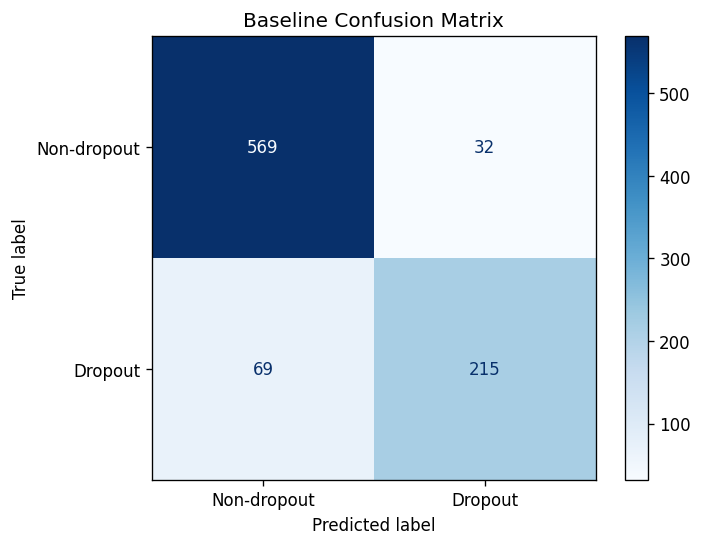

In [28]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions,
    display_labels=['Non-dropout', 'Dropout'],
    cmap='Blues'
)
plt.title('Baseline Confusion Matrix')
plt.show()


The baseline performs well overall, although recall for the dropout class is lower than recall for the non-dropout class.


The predicted labels can also be inspected directly.


In [29]:
print('Predictions:', predictions)

Predictions: [0 0 1 0 1 0 1 1 0 1 1 0 1 0 0 0 1 0 1 0 0 0 0 0 1 0 0 1 1 1 0 1 1 1 0 1 0
 1 1 0 0 1 0 0 0 0 0 0 1 0 1 1 1 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 1
 0 1 0 1 1 1 0 0 0 1 0 0 0 0 0 0 1 0 1 0 0 0 0 1 0 0 1 0 1 0 0 1 0 0 1 1 0
 0 0 1 0 1 0 1 0 0 0 0 1 0 0 0 0 1 0 0 1 0 0 1 0 1 0 1 1 0 1 0 0 0 1 0 0 0
 0 1 0 0 0 0 0 0 0 1 0 0 0 0 1 0 1 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0
 1 1 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 1
 1 0 0 0 0 0 0 1 0 0 1 0 0 1 0 1 1 1 0 1 0 0 0 0 0 0 0 0 0 0 1 0 1 0 1 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 1 0 0 0 0 1 1 1 1 0 0 1 1 0 0 1 0 0 0 0
 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 1 0 0 0 1 1 1
 0 1 0 1 0 1 0 0 1 0 1 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 1 0 1 0 0 1 0
 1 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1 1 0 1 1 0 1 0 0 1 0 1 1 0 0
 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 1 1 0 1 0 0 0 0 1
 1 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 1 0 0 0 0 0
 0 0 0 0 0 0

## Model selection and hyperparameter tuning

The next stage compares alternative resampling methods, dimensionality-reduction choices, classifiers, and hyperparameters.


The search has three aims:


- **Optimization:** tune the internal settings of each algorithm.


- **Comparison:** evaluate several model families under the same cross-validation procedure.


- **Stability:** check whether performance is consistent across different training folds.


### Sampler configurations

The dropout class is less frequent, so the search compares no resampling, random over-sampling, random under-sampling, and SMOTE.


- None: Keep the data as is (The baseline).

- RandomOverSampler(): Duplicate random rows of dropout students until they match the number of graduates.

- RandomUnderSampler(): Delete random rows of graduate students until they match the dropouts.

- SMOTE: Create synthetic students by looking at the characteristics of existing dropouts and creating new, similar profiles.

In [30]:
sampler_configs = [
    {'sampler': [None]}, # No resampling
    {
        'sampler': [RandomOverSampler(random_state=42)],
        'sampler__sampling_strategy': ['minority']
    },
    {
        'sampler': [RandomUnderSampler(random_state=42)],
        'sampler__sampling_strategy': ['majority']
    },
    {
        'sampler' : [SMOTE(random_state=42)]
    }
]

### Dimensionality reduction

We test if reducing our features into a smaller set of principal components improves the signal-to-noise ratio. Too much information can confuse a model.

- **PCA:** retains a chosen proportion of explained variance in a lower-dimensional representation.


- LDA(): This mathematically squashes the data into a single dimension that best separates Graduates from Dropouts.

In [31]:
dim_reduction_configs = [
    {'dim_reduction': [None]},  # No dimensionality reduction
    {
        'dim_reduction': [PCA(random_state=42)],
        'dim_reduction__n_components': [0.7, 0.8, 0.9]
    },
    {
        'dim_reduction': [LDA(n_components=1)]
    }
]


### Classifier configurations

We will compare the performance of 4 different ML algorithms to then evaluate which performs better and with which parameters. By testing different hyperparameters, we are fine-tuning these algorithms to fit the specific patterns in the dataset.

1. Logistic Regression: This model calculates the probability of a student dropping out.

- C (Inverse Regularization Strength): It governs the tradeoff between fitting the training data accurately and maintaining model simplicity. A smaller C increases the regularization penalty, leading to a simpler model, whereas a larger C reduces the penalty, allowing for a more complex fit.

- L1 (Lasso): Acts like a filter. If features have zero impact on dropouts, L1 will ignore them entirely.

- L2 (Ridge): Keeps all features but shrinks their influence so no single variable overwhelms the others.

2. Perceptron: It learns by looking at a student's record and making a guess. If it's wrong, it adjusts its weights.

- eta0 (Learning Rate): This determines how big of a jump the model makes when it learns something new.

3. K-Neighbors Classifier: It makes predictions by identifying the 'K' most similar data points (neighbors) in the training set and assigning the class label most common among them.

- n\_neighbors \[3, 5, 7, 9\]: To predict if Student A will drop out, it finds the n most similar students in the history of the dataset. If most of those neighbors dropped out, it predicts Student A will too.

4. Random Forest: This is an ensemble method that builds multiple decision trees and merges them together to get a more accurate and stable prediction.

- n\_estimators \[10, 50, 100, 500\]: This controls the number of trees in the forest. More trees generally lead to better performance and stability but take longer to compute.

- max\_depth \[None, 10, 20\]: This limits how deep each tree can grow. A deeper tree can capture very complex patterns but risks memorizing the training data (overfitting). Limiting the depth forces the model to learn more general rules that apply to new students.

In [32]:
classifier_configs = [
    # Logistic Regression

    # L1-regularization
    {
        'classifier': [LogisticRegression(max_iter=1000, random_state=42)],
        'classifier__C': np.logspace(-2, 2, 5),
        'classifier__penalty': ['l1'],
        'classifier__solver': ['saga', 'liblinear']
    },
    # L2-regularization
    {
        'classifier': [LogisticRegression(max_iter=1000, random_state=42)],
        'classifier__C': np.logspace(-2, 2, 5),
        'classifier__penalty': ['l2'],
        'classifier__solver': ['lbfgs']
    },
    # Perceptron
    {
        'classifier': [Perceptron(random_state=42)],
        'classifier__max_iter': [50, 100, 200],
        'classifier__eta0' : loguniform(0.001, 10)
    },
    # KNN
    {
        'classifier': [KNeighborsClassifier(n_jobs=1)],
        'classifier__n_neighbors': [3, 5, 7, 9]
    },
    # Random Forest
    {
        'classifier': [RandomForestClassifier(random_state=42, n_jobs=1)],
        'classifier__n_estimators': [10, 50, 100, 500],
        'classifier__max_depth': [None, 10, 20] # helps prevent overfitting
    }
]

Sequential Feature Selection was not included in the final search because preliminary runs added substantial computation without a clear improvement. L1-regularized logistic regression still provides embedded feature selection.


### Cartesian product generation

To identify the optimal model architecture, we now generate a Cartesian product of all preprocessing and classification configurations.

In [33]:
pipeline_configs = [
    dict(itertools.chain(*(e.items() for e in configuration)))
    for configuration in itertools.product(
        sampler_configs,
        dim_reduction_configs,
        classifier_configs
    )
]

f'Number of all possible configurations: {len(pipeline_configs)}'

'Number of all possible configurations: 60'

The Cartesian product contains 60 pipeline configurations before their internal hyperparameter choices are sampled.


### Nested cross-validation

Nested cross-validation is used to evaluate the model-selection procedure on the training split.


- **Inner loop:** `RandomizedSearchCV` compares sampled configurations with three-fold cross-validation.


In [34]:
random_search = RandomizedSearchCV(
    starting_pipeline,
    param_distributions=pipeline_configs,
    n_iter=200,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=0,
    random_state=42
)


- **Outer loop:** five folds estimate how the complete search procedure performs on held-out portions of the training data. The outer-fold scores are summarized rather than treated as five independent final models.


In [35]:
with parallel_backend('threading', n_jobs=-1):
    scores = cross_validate(
        random_search,
        X_train,
        y_train,
        scoring='f1',
        cv=5,
        return_estimator=True,
        return_train_score=True,
        verbose=0,
        n_jobs=1
    )


## Results and performance analysis

The selected configuration from each outer fold and its F1-score are shown below.


In [36]:
print(
    f"Outer-fold F1: {scores['test_score'].mean():.4f} "
    f"+/- {scores['test_score'].std():.4f}"
)
print()

for idx, estimator in enumerate(scores['estimator']):
    best_params = estimator.best_estimator_.get_params()
    print(f"Outer fold {idx + 1}:")
    print(f"  Sampler:         {best_params['sampler']}")
    print(f"  Dim reduction:   {best_params['dim_reduction']}")
    print(f"  Classifier:      {best_params['classifier']}")
    print(f"  F1-score:        {scores['test_score'][idx]:.4f}")
    print("-" * 40)


Outer-fold F1: 0.7869 +/- 0.0129

Outer fold 1:
  Sampler:         RandomOverSampler(random_state=42, sampling_strategy='minority')
  Dim reduction:   None
  Classifier:      RandomForestClassifier(n_estimators=500, n_jobs=1, random_state=42)
  F1-score:        0.8027
----------------------------------------
Outer fold 2:
  Sampler:         None
  Dim reduction:   None
  Classifier:      LogisticRegression(C=np.float64(1.0), max_iter=1000, penalty='l1',
                   random_state=42, solver='saga')
  F1-score:        0.7749
----------------------------------------
Outer fold 3:
  Sampler:         RandomOverSampler(random_state=42, sampling_strategy='minority')
  Dim reduction:   None
  Classifier:      RandomForestClassifier(n_estimators=500, n_jobs=1, random_state=42)
  F1-score:        0.7770
----------------------------------------
Outer fold 4:
  Sampler:         None
  Dim reduction:   None
  Classifier:      LogisticRegression(C=np.float64(1.0), max_iter=1000, penalty='l1',


### Final model evaluation

The outer folds selected L1-regularized logistic regression three times and random forest twice, with similar F1-scores. The final candidate uses L1-regularized logistic regression for interpretability and random over-sampling to address class imbalance. Its regularization strength is tuned again on the full training split.


Final pipeline architecture:

In [37]:
selected_pipeline = IMBPipeline([
    ('preprocessor', preprocessor),
    ('sampler', RandomOverSampler(random_state=42, sampling_strategy='minority')),
    ('classifier', LogisticRegression(
        random_state=42,
        penalty='l1',
        solver='liblinear',
        C=1.0,
        max_iter=5000
    ))
])

The final logistic-regression pipeline uses a higher iteration limit to ensure convergence when fitted on the full training split.


A final search selects the regularization strength `C` for the chosen pipeline.


Smaller values of `C` apply stronger regularization; larger values allow a more flexible fit.


In [38]:
params = {
    'classifier__C': [0.01, 0.1, 1, 10, 50, 100]
}

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=1, random_state=42)

rs_best = RandomizedSearchCV(
    estimator=selected_pipeline,
    param_distributions=params,
    cv=cv,
    n_iter=6,
    scoring='f1',
    random_state=42,
    n_jobs=-1,
    verbose=0
)


Let's check explicitly which are the best hyperparameters of our model.

In [39]:
# Fit the selected pipeline and tune its regularization strength
with parallel_backend('threading', n_jobs=-1):
    rs_best.fit(X_train, y_train)

print(f"Best C found: {rs_best.best_params_['classifier__C']}")
print(f"Best cross-validated F1: {rs_best.best_score_:.4f}")


Best C found: 1
Best cross-validated F1: 0.7865


The tuned pipeline is evaluated once on the held-out test set. Training and test F1-scores are shown together to check the generalization gap.


In [40]:
# Final prediction on the untouched X_test
y_test_pred = rs_best.predict(X_test)
final_f1 = f1_score(y_test, y_test_pred)

# Performance on Training set (to compare and check for overfitting)
y_train_pred = rs_best.predict(X_train)
train_f1 = f1_score(y_train, y_train_pred)

--- Final Model Performance ---
F1 Score on Training Set: 0.8003
F1 Score on Test Set:     0.8142
Generalization Gap:       -0.0138
-----------------------------------


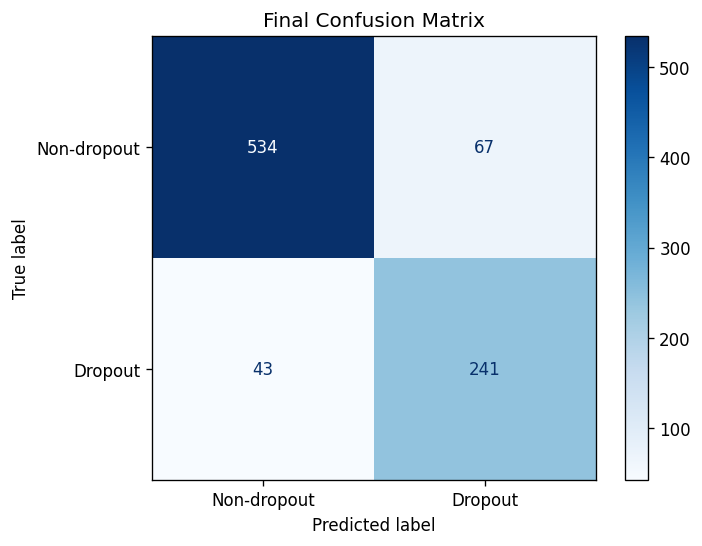

In [41]:
print("--- Final Model Performance ---")
print(f"F1 Score on Training Set: {train_f1:.4f}")
print(f"F1 Score on Test Set:     {final_f1:.4f}")
print(f"Generalization Gap:       {train_f1 - final_f1:.4f}")
print("-" * 35)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    display_labels=['Non-dropout', 'Dropout'],
    cmap='Blues',
)

plt.title("Final Confusion Matrix")
plt.show()


- **Top-left (true non-dropout):** non-dropout students correctly classified as non-dropout.


- **Bottom-right (true dropout):** dropout students correctly identified.


- **Bottom-left (missed dropout):** dropout students predicted as non-dropout.


- **Top-right (false alarm):** non-dropout students predicted as dropout.


Now, we can visualize the learning curve and the validation curve to quantify the bias/variance trade-off as a function of the size of the training set and the variation of the hyperparameter

C.

### Learning Curve

The learning curve compares training and validation F1 as the training sample grows. It helps diagnose high bias or high variance and shows whether additional data may still be useful.


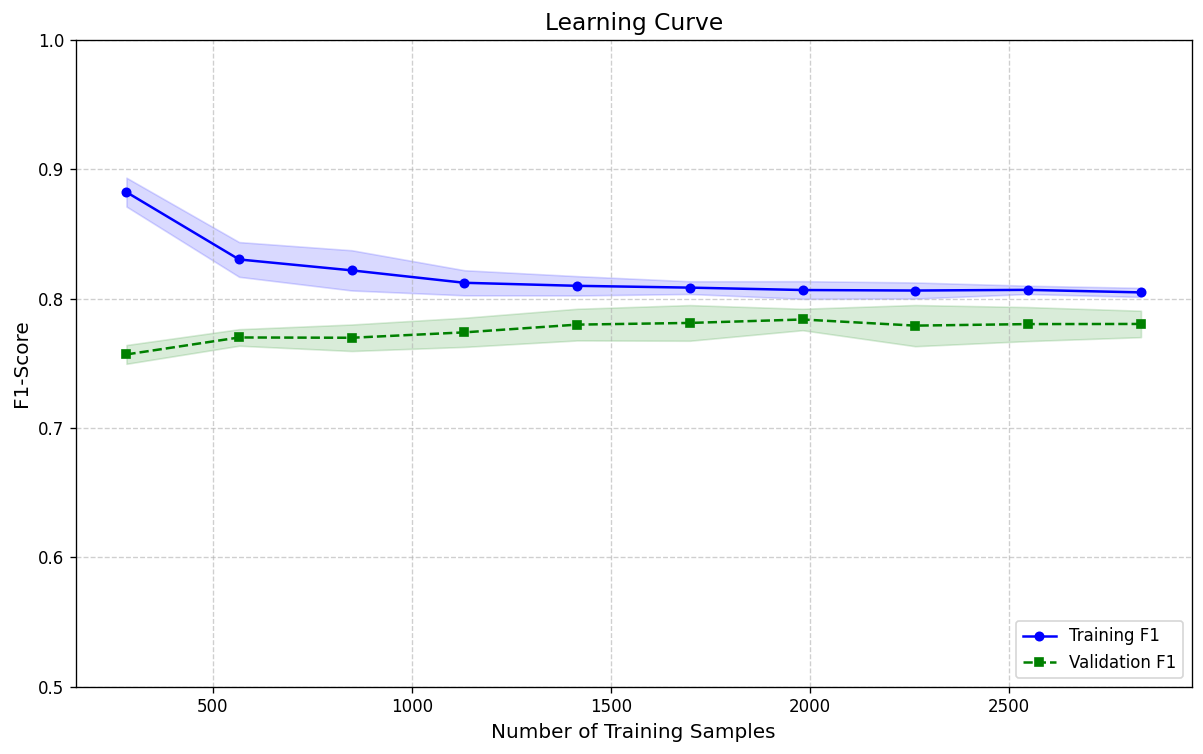

In [42]:
best_estimator = rs_best.best_estimator_

# Calculate the learning curve
train_sizes, train_scores, test_scores = learning_curve(
    best_estimator,
    X_train,
    y_train,
    cv=5, # 5-fold cross-validation
    scoring='f1',
    n_jobs=1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    shuffle=True,
    random_state=42
)

# Calculate means and standard deviations
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Visualization
plt.figure(figsize=(12, 7))

# Plot Training F1
plt.plot(train_sizes, train_mean,
         color='blue', marker='o',
         markersize=5, label='Training F1')
plt.fill_between(train_sizes,
                 train_mean + train_std,
                 train_mean - train_std,
                 alpha=0.15, color='blue')

# Plot Validation F1 ('test_scores' from the CV)
plt.plot(train_sizes, test_mean,
         color='green', linestyle='--',
         marker='s', markersize=5,
         label='Validation F1')
plt.fill_between(train_sizes,
                 test_mean + test_std,
                 test_mean - test_std,
                 alpha=0.15, color='green')

# Formatting
plt.title('Learning Curve', fontsize=14)
plt.xlabel('Number of Training Samples', fontsize=12)
plt.ylabel('F1-Score', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='lower right')
plt.ylim([0.5, 1.0])
plt.show()

The training and validation curves become closer as more samples are used, which is consistent with limited overfitting in this experiment.


The validation curve begins to level off at larger sample sizes. This suggests diminishing returns within the observed range, but it does not prove that more or more varied data would provide no benefit.


### Validation Curve

We now want to verify that the model is correctly optimized, and to do that we use the Validation Curve.

The validation curve shows how the F1-score changes with the logistic-regression regularization parameter `C`.


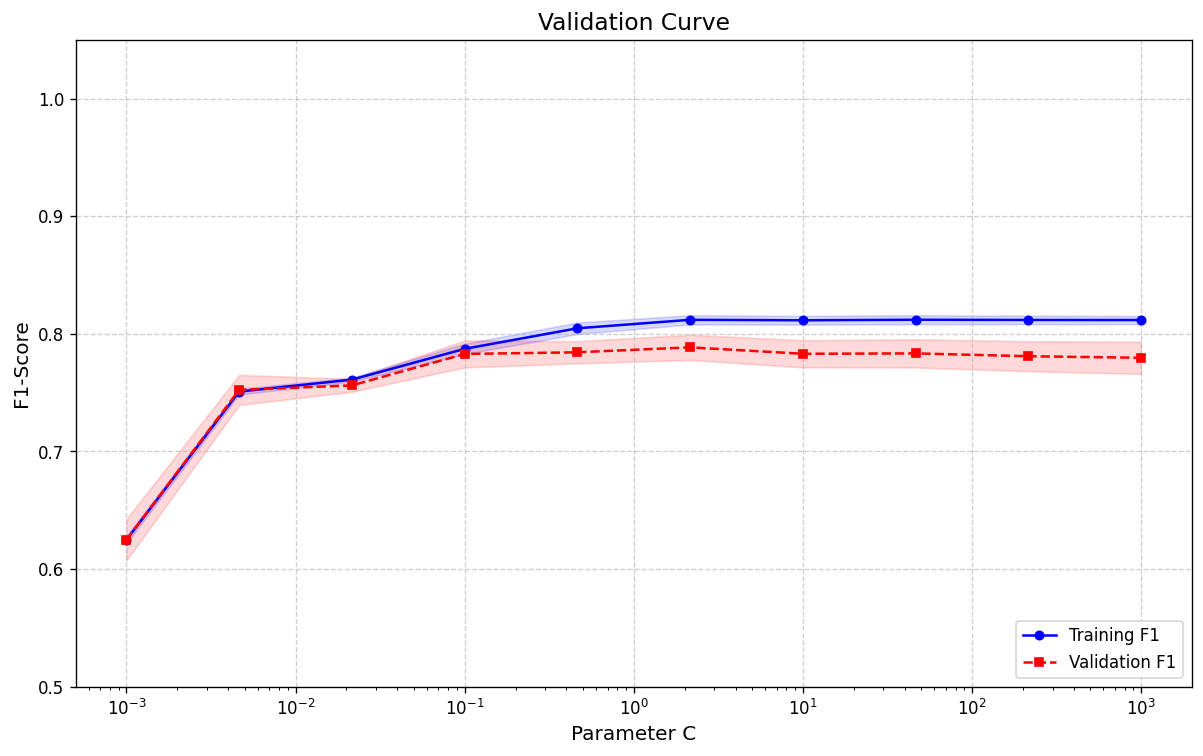

In [43]:
param_range = np.logspace(-3, 3, 10)  # C range

# Calculate the validation curve
train_scores, test_scores = validation_curve(
    best_estimator,
    X_train,
    y_train,
    param_name='classifier__C',
    param_range=param_range,
    cv=5,
    n_jobs=1,
    scoring='f1'
)

# Calculate means and standard deviations
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Visualization
plt.figure(figsize=(12, 7))

# Training Score
plt.plot(param_range, train_mean,
         color='blue', marker='o',
         markersize=5, label='Training F1')
plt.fill_between(param_range,
                 train_mean + train_std,
                 train_mean - train_std,
                 alpha=0.15, color='blue')

# Validation Score
plt.plot(param_range, test_mean,
         color='red', linestyle='--',
         marker='s', markersize=5,
         label='Validation F1')
plt.fill_between(param_range,
                 test_mean + test_std,
                 test_mean - test_std,
                 alpha=0.15, color='red')

# Formatting
plt.title('Validation Curve', fontsize=14)
plt.xlabel('Parameter C', fontsize=12)
plt.ylabel('F1-Score', fontsize=12)
plt.xscale('log') # Log scale is essential for C
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='lower right')
plt.ylim([0.5, 1.05])
plt.show()

The curve is relatively stable across a broad range of `C` values, with the best region close to the value selected by cross-validation.


Very small values apply stronger regularization and reduce both training and validation scores. At larger values, the gap between the two curves increases slightly.


The selected value therefore provides a reasonable balance between fit and generalization for this training split.


## Conclusion

This notebook develops an interpretable binary classifier for dropout risk after two semesters of study.


The final pipeline combines random over-sampling with L1-regularized logistic regression and is evaluated on a held-out test set.


L1 regularization provides embedded feature selection without adding the computational cost of a separate sequential feature-selection step.


Logistic regression was preferred to the tested non-linear alternatives because it combines competitive performance with coefficients that can be inspected.


The largest positive coefficients identify categories most strongly associated with the model's dropout prediction. They should be interpreted as model associations, not causal effects.


In [44]:
feature_names = rs_best.best_estimator_.named_steps['preprocessor'].get_feature_names_out()
coefficients = rs_best.best_estimator_.named_steps['classifier'].coef_[0]

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Largest positive associations with the predicted dropout class
top_dropout_associations = importance_df.sort_values(
    by='Coefficient', ascending=False
).head(5)

print("--- Largest Positive Coefficients for Dropout ---")
print(top_dropout_associations[['Feature', 'Coefficient']].to_string(index=False))


--- Largest Positive Coefficients for Dropout ---
                      Feature  Coefficient
cat__previous_qualification_4     2.181198
cat__fathers_qualification_40     1.816057
cat__mothers_qualification_34     1.655850
   cat__fathers_occupation_90     1.295770
             cat__course_9853     1.247346


The fitted coefficients highlight several background and course categories alongside academic and financial variables.


These associations describe this dataset and model only; they do not establish that any feature causes a student to drop out.


## References

- [Scikit-learn User Guide](https://scikit-learn.org/stable/user_guide.html)


- Realinho, V., Vieira Martins, M., Machado, J., & Baptista, L. (2021). *Predict Students' Dropout and Academic Success*. UCI Machine Learning Repository. https://doi.org/10.24432/C5MC89


- Dataset license: [Creative Commons Attribution 4.0 International](https://creativecommons.org/licenses/by/4.0/).
